# v-Sequence Deep Dive

The v-sequence of a number n is the sequence of 2-adic valuations at each Syracuse step. If v-sequences were truly random (i.i.d. geometric), the Collatz conjecture would follow easily from probabilistic arguments. The question is: what structure do v-sequences actually have?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collatz.core import v_sequence

## Autocorrelation of v-sequences

If consecutive v-values are independent, autocorrelation at all lags should be ~0.

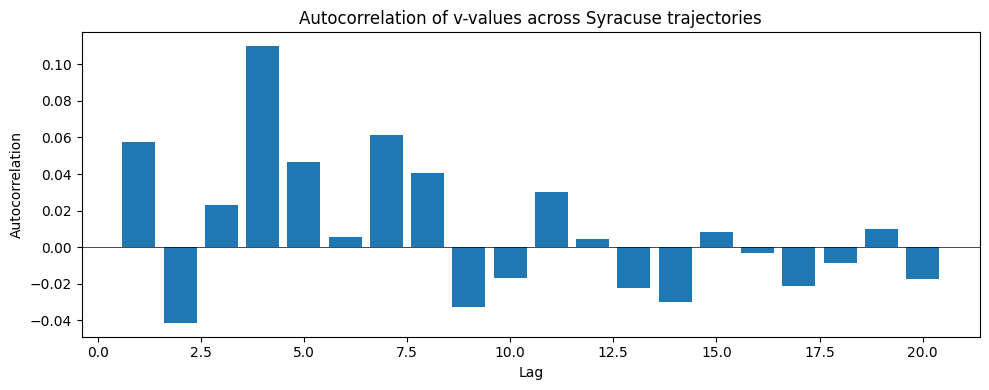

Lag-1 autocorrelation: 0.057793


In [2]:
all_vs = []
for n in range(3, 100_001, 2):
    all_vs.extend(v_sequence(n))
all_vs = np.array(all_vs)

mean_v = np.mean(all_vs)
var_v = np.var(all_vs)
max_lag = 20
autocorr = []
for lag in range(1, max_lag + 1):
    c = np.mean((all_vs[:-lag] - mean_v) * (all_vs[lag:] - mean_v)) / var_v
    autocorr.append(c)

plt.figure(figsize=(10, 4))
plt.bar(range(1, max_lag + 1), autocorr)
plt.axhline(y=0, color="k", linewidth=0.5)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of v-values across Syracuse trajectories")
plt.tight_layout()
plt.show()

print(f"Lag-1 autocorrelation: {autocorr[0]:.6f}")

## Conditional distribution: P(v_{i+1} | v_i)

Does the current v-value predict the next one?

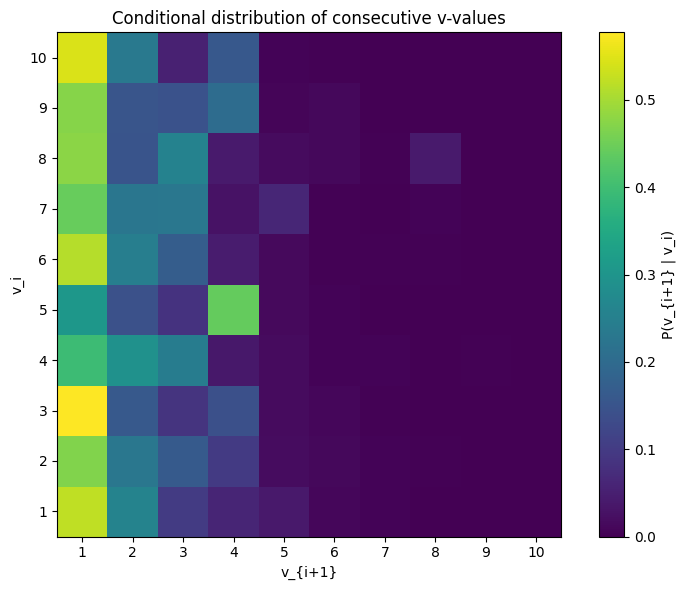

KL(P(v_next | v_prev=1) || marginal) = 0.008010
KL(P(v_next | v_prev=2) || marginal) = 0.019995
KL(P(v_next | v_prev=3) || marginal) = 0.075677
KL(P(v_next | v_prev=4) || marginal) = 0.074404
KL(P(v_next | v_prev=5) || marginal) = 0.577003


In [3]:
max_v = 10
transitions = np.zeros((max_v, max_v))

for n in range(3, 100_001, 2):
    vs = v_sequence(n)
    for i in range(len(vs) - 1):
        a, b = vs[i], vs[i + 1]
        if a <= max_v and b <= max_v:
            transitions[a - 1, b - 1] += 1

row_sums = transitions.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cond_prob = transitions / row_sums

plt.figure(figsize=(8, 6))
plt.imshow(cond_prob, cmap="viridis", origin="lower")
plt.colorbar(label="P(v_{i+1} | v_i)")
plt.xlabel("v_{i+1}")
plt.ylabel("v_i")
plt.xticks(range(max_v), range(1, max_v + 1))
plt.yticks(range(max_v), range(1, max_v + 1))
plt.title("Conditional distribution of consecutive v-values")
plt.tight_layout()
plt.show()

marginal = np.array([1 / 2**k for k in range(1, max_v + 1)])
marginal /= marginal.sum()
for v_prev in range(1, 6):
    row = cond_prob[v_prev - 1]
    kl = np.sum(row * np.log(row / marginal + 1e-10))
    print(f"KL(P(v_next | v_prev={v_prev}) || marginal) = {kl:.6f}")

## v-sequence as a function of binary representation

Does the binary structure of n predict its v-sequence? Numbers with the same low bits (mod 2^k) should share v-sequence prefixes.

In [4]:
k = 8
mod = 2**k
r = 3

vs_for_class = []
for n in range(r, 100_000, mod):
    if n > 0 and n % 2 == 1:
        vs = v_sequence(n)
        vs_for_class.append(vs[:10] if len(vs) >= 10 else vs)

for prefix_len in range(1, 8):
    prefixes = [tuple(vs[:prefix_len]) for vs in vs_for_class if len(vs) >= prefix_len]
    if prefixes:
        most_common = max(set(prefixes), key=prefixes.count)
        frac = prefixes.count(most_common) / len(prefixes)
        print(f"Prefix length {prefix_len}: most common = {most_common}, fraction = {frac:.4f}")

Prefix length 1: most common = (1,), fraction = 1.0000
Prefix length 2: most common = (1, 4), fraction = 1.0000
Prefix length 3: most common = (1, 4, 2), fraction = 1.0000
Prefix length 4: most common = (1, 4, 2, 1), fraction = 0.5000
Prefix length 5: most common = (1, 4, 2, 1, 1), fraction = 0.2513
Prefix length 6: most common = (1, 4, 2, 1, 1, 1), fraction = 0.1256
Prefix length 7: most common = (1, 4, 2, 1, 1, 1, 1), fraction = 0.0615
